> Basado en [Brain Tumor Classification](https://www.kaggle.com/code/mazennmohamed/brain-tumor-classification)
> de mazenn mohamed (Apache 2.0).

#**Brain Tumor MRI Classification Using Deep Learning**
---
**Dataset:** Brain Tumor MRI Dataset (Kaggle)  
**Environment:** Kaggle Notebook | GPU Enabled  
**Framework:** TensorFlow / Keras

### Brain Tumor Classification

Brain tumors are one of the most dangerous and life-threatening medical conditions worldwide. Early and **accurate diagnosis** is critical for treatment planning and patient survival. However, manually analyzing MRI scans requires highly trained radiologists, which is time-consuming and prone to human error.

By applying **deep learning image classification**, we can:
- Assist doctors in detecting tumor types faster and more accurately
- Provide a second opinion in resource-limited hospitals
- Potentially save lives through earlier detection

### Classes in our dataset:
1. **Glioma** – A tumor arising from glial cells, often aggressive
2. **Meningioma** – A tumor of the meninges (brain lining), usually slower-growing
3. **Pituitary** – A tumor in the pituitary gland
4. **No Tumor** – Healthy brain MRI scans

> **Dataset:** [Brain Tumor MRI Dataset on Kaggle](https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset)  
> **Total Images:** ~7,000+
> **Classes:** 4

## Imports & Setup

In [1]:
# ─── Standard Libraries ───────────────────────────────────────────────────────
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
#warnings.filterwarnings('ignore')

# ─── TensorFlow / Keras ───────────────────────────────────────────────────────
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import (
    VGG16, ResNet50, InceptionV3, MobileNetV2, EfficientNetB0   #Pre-trained Models
)

import kagglehub

accuracy / precision / recall: how accurate the model is, overall and by error type.

In [2]:
# ─── Evaluation Metrics ───────────────────────────────────────────────────────
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score
)

GPUs move data between their memory and their cores much faster than a CPU. In deep learning, using the GPU as a processor reduces computational cost.

In [3]:
# ─── GPU Check ────────────────────────────────────────────────────────────────
print('TensorFlow version:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')
print('GPU Available:', gpus if gpus else 'No GPU – check Kaggle settings!')

TensorFlow version: 2.21.0
GPU Available: No GPU – check Kaggle settings!


BATCH_SIZE: The model processes 32 images at a time before updating its weights.

EPOCHS: Maximum number of complete passes through the dataset. EarlyStopping may cut this short.

NUM_CLASSES: Output categories (glioma, meningioma, pituitary, and no tumor).

SEED: Random seed to make results more reproducible.

In [4]:
# ─── Global Config ────────────────────────────────────────────────────────────
IMG_SIZE    = (224, 224)   # Standard size for transfer learning models
BATCH_SIZE  = 32
EPOCHS      = 20           # EarlyStopping will cut this short when needed
NUM_CLASSES = 4
SEED        = 42
tf.random.set_seed(SEED)

## Data Preparation

We use **ImageDataGenerator** to:
- Load images directly from folders
- Rescale pixel values from [0–255] to [0–1]
- Apply data augmentation on the training set to prevent overfitting

In [5]:
path = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')
print('Dataset en:', path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Dataset en: /kaggle/input/brain-tumor-mri-dataset


In [6]:
# ─── Dataset Paths ────────────────────────────────────────────────────────────
BASE_DIR  = path  #Main Folder
TRAIN_DIR = os.path.join(BASE_DIR, 'Training') #Trainig Folder
TEST_DIR  = os.path.join(BASE_DIR, 'Testing') #Testing Folder

# Print class names (folder names = class labels)
class_names = sorted(os.listdir(TRAIN_DIR))  #os.listdir returns the names of the contents of a folder
print('Classes found:', class_names)

# Count images per class
for cls in class_names:
    n = len(os.listdir(os.path.join(TRAIN_DIR, cls)))
    print(f'  {cls}: {n} training images')

Classes found: ['glioma', 'meningioma', 'notumor', 'pituitary']
  glioma: 1400 training images
  meningioma: 1400 training images
  notumor: 1400 training images
  pituitary: 1400 training images


ImageDataGenerator --> Class

train_datagen, test_datagen --> objects

In [8]:
# ─── Training Generator (with augmentation) ───────────────────────────────────
"""(data) augmentation consist of generating random varations in the training images
    to obtain more training data """
train_datagen = ImageDataGenerator(
    rescale=1.0/255,           # Normalize pixel values to [0, 1] (STANDAR rescaling)
    rotation_range=20,         # Randomly rotate images ±20 degrees
    width_shift_range=0.15,    # Horizontal shift
    height_shift_range=0.15,   # Vertical shift
    zoom_range=0.15,           # Random zoom in/out
    horizontal_flip=True,      # Mirror images horizontally
    brightness_range=[0.8, 1.2],  # Random brightness variation
    validation_split=0.2       # 20% of training data used for validation
)

# ─── Validation/Test Generator (NO augmentation, only rescaling) ──────────────
test_datagen = ImageDataGenerator(rescale=1.0/255)

flow_from_directory --> method.

It connects an image folder to the model. It reads the images from the disk, prepares them, and delivers them in batches, with their labels already assigned.

In [9]:
# ─── Training Set (80% of Training folder) ────────────────────────────────────
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # One-hot encoded labels
    subset='training',
    seed=SEED,
    shuffle=True
)

Found 4480 images belonging to 4 classes.


In [10]:
# ─── Validation Set (20% of Training folder) ──────────────────────────────────
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=SEED,
    shuffle=False
)

Found 1120 images belonging to 4 classes.


After training --> TEST

In [11]:
# ─── Test Set (separate Testing folder) ───────────────────────────────────────
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False   # IMPORTANT: don't shuffle test set so labels stay in order
)

Found 1600 images belonging to 4 classes.


In [12]:
print(f'\nTraining samples  : {train_generator.samples}')
print(f'Validation samples: {val_generator.samples}')
print(f'Test samples      : {test_generator.samples}')
print(f'Class indices     : {train_generator.class_indices}')


Training samples  : 4480
Validation samples: 1120
Test samples      : 1600
Class indices     : {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


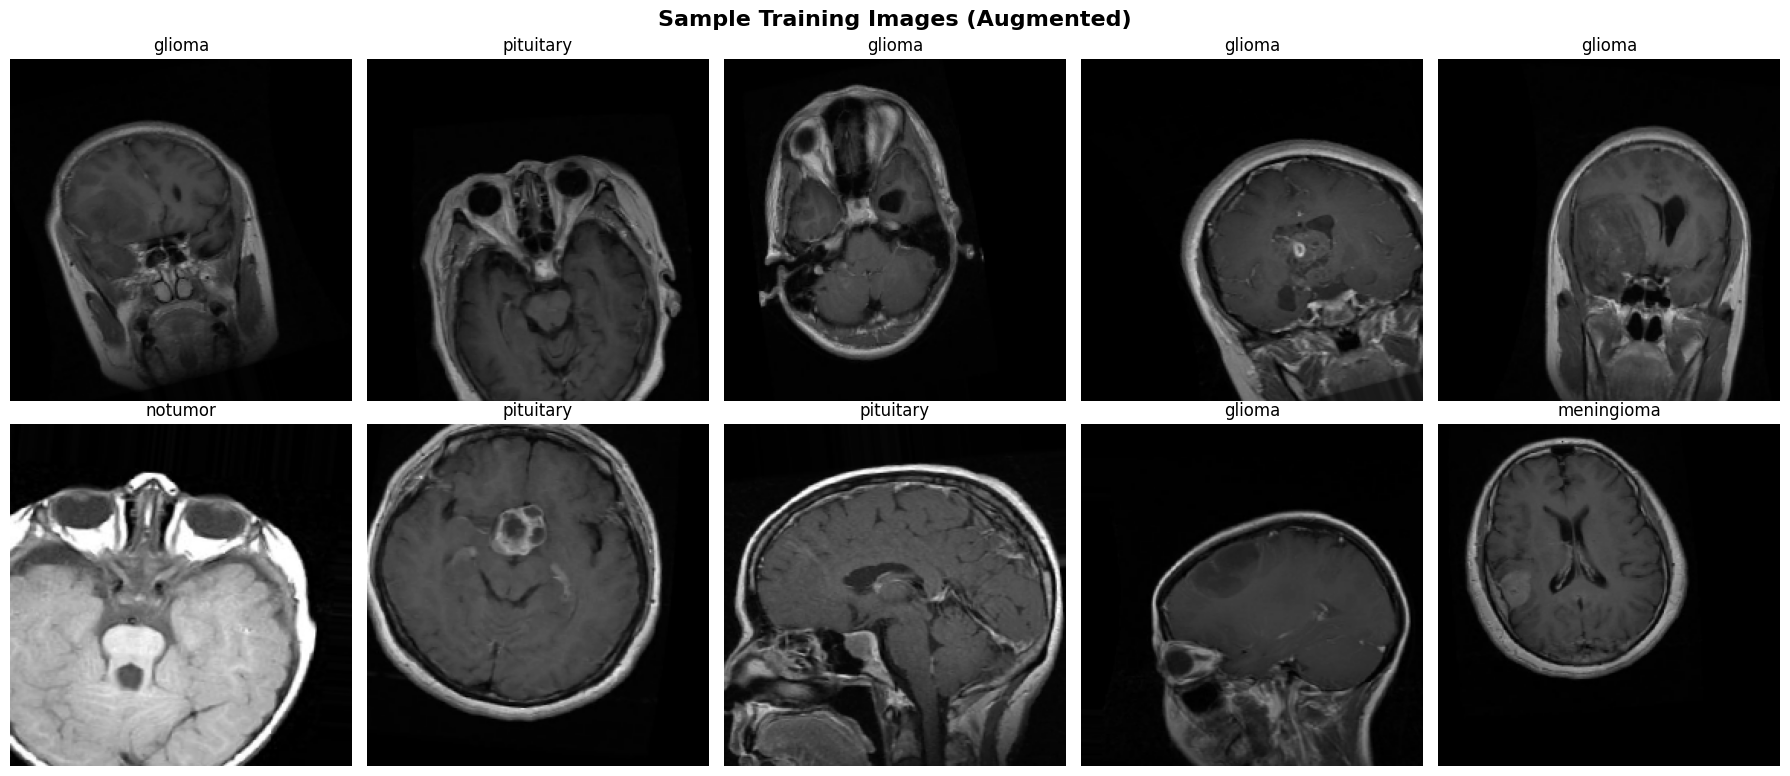

In [13]:
# ─── Visualize Sample Images ──────────────────────────────────────────────────
images, labels = next(train_generator)
label_map = {v: k for k, v in train_generator.class_indices.items()}

fig, axes = plt.subplots(2, 5, figsize=(18, 8))
fig.suptitle('Sample Training Images (Augmented)', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(label_map[np.argmax(labels[i])], fontsize=12)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Callbacks Setup

We define reusable callbacks that will be applied to **every model** during training:
- **EarlyStopping**: Stops training when validation loss stops improving (prevents overfitting)
- **ModelCheckpoint**: Saves the best version of the model during training
- **ReduceLROnPlateau**: Reduces the learning rate when progress stalls

In [17]:
def get_callbacks(model_name):
    """Returns a list of training callbacks for a given model name."""

    # Stop training early if val_loss doesn't improve for 5 consecutive epochs
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True,  # Roll back to the best weights found
        verbose=1
    )

    # Save the model whenever val_accuracy improves
    checkpoint = ModelCheckpoint(
        filepath=f'{model_name}_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    # Reduce learning rate by half if val_loss doesn't improve for 3 epochs
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    )

    return [early_stop, checkpoint, reduce_lr]

val_loss --> How much the model errs on the validation images. This measure give us confidence if is value is low.

val_accuracy --> correct answers percentage on the validation images. This measure give us confidence if is value is high.

## Helper Functions

We define reusable functions to **plot training curves** and **evaluate models** so we don't repeat code for each of the 5 models.

Learning curves allow us to visualizate the model epoch by epoch.

In [18]:
#Learning Curves
def plot_history(history, model_name):
    """Plot training and validation accuracy/loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'{model_name} – Training Curves', fontsize=14, fontweight='bold')

    # ── Accuracy Plot ──
    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', color='steelblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   color='darkorange')
    axes[0].set_title('Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── Loss Plot ──
    axes[1].plot(history.history['loss'],     label='Train Loss', color='steelblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   color='darkorange')
    axes[1].set_title('Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

model evaluation. Comparison between correct answers and predictions by model and visualization using confusion matrix.

In [19]:
def evaluate_model(model, generator, model_name, class_names): #model: trained model, genrator: Test images
    """Evaluate model: accuracy, precision, recall, confusion matrix."""
    generator.reset()  # Reset to start of dataset (first image)

    # Get true labels and predictions
    y_true = generator.classes  #correct answers
    y_pred_probs = model.predict(generator, verbose=1)  #the model return 4 confidence percentages for each image
    y_pred = np.argmax(y_pred_probs, axis=1) #Take the max value for image

    #Comparations between model (y_pred) and correct answers (y_true)
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted')
    rec  = recall_score(y_true, y_pred, average='weighted')


    #Print Values
    print(f'\n=== {model_name} – Test Evaluation ===')
    print(f'  Accuracy : {acc:.4f} ({acc*100:.2f}%)')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall   : {rec:.4f}')

    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, target_names=class_names))

    # ── Confusion Matrix Plot ──
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} – Confusion Matrix', fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

    return acc, prec, rec

In the **Confusion Matrix**, correct results are located along the diagonal. Outsite of it, we can see errs, it means confusions between classes. A high number outside the diagonal indicate a significant error. We represente it using a heatmap.

In [20]:
# Dictionary to store all model histories and results for final comparison
all_histories = {}
all_results   = {}

## **Model Building & Training**

We will train **5 models** total:
1. **Custom CNN** – built from scratch by us
2. **VGG16** – Transfer Learning
3. **ResNet50** – Transfer Learning
4. **MobileNetV2** – Transfer Learning
5. **EfficientNetB0** – Transfer Learning



---
**Model construction --> Compilating --> Training --> Evaluating**

---
###  Model 1: Custom CNN

In [21]:
# ─── Build Custom CNN Architecture ────────────────────────────────────────────
# We use a pretrained MobileNetV2 as a frozen feature extractor, then attach
# a fully custom-designed classification head on top.
# The head (all layers after GlobalAveragePooling2D) is our original design.

def build_custom_cnn(input_shape=(224, 224, 3), num_classes=4):
    # ── Pretrained Feature Extractor (frozen) ────────────────────────────────
    base = keras.applications.MobileNetV2(
        weights='imagenet',     # Use ImageNet pretrained weights
        include_top=False,      # Remove the original classification head
        input_shape=input_shape  #images 224x224 pixeles
    )
    base.trainable = False      # Freeze all base layers initially

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)   # Forward pass through frozen base


    # ── Custom Classification Head (designed by us) ───────────────────────────
    x = layers.GlobalAveragePooling2D()(x)        # Reduce feature maps to 1D vector
    x = layers.Dense(512, activation='relu')(x)   # First custom dense layer
    x = layers.BatchNormalization()(x)             # Normalize activations
    x = layers.Dropout(0.4)(x)                    # Prevent overfitting
    x = layers.Dense(256, activation='relu')(x)   # Second custom dense layer
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)  # Output probabilities

    model = keras.Model(inputs, outputs, name='Custom_CNN')
    return model

- optimizer=Adam(learning_rate=0.0001): the optimizer is the algorithm that adjusts the weights. Adam is one of the most widely used because it automatically adapts the step size. learning_rate=0.0001 is the initial learning rate (the step size), it is a small, reasonable value to avoid disrupting a pre-trained base. This is the rate that ReduceLROnPlateau will cut in half.

- loss='categorical_crossentropy': the loss function, the metric used to measure the model's error, corresponds to the loss and val_loss values ​​monitored by the callbacks. It is designed for one-hot encoded labels and aligns with the generators' class_mode='categorical' setting. It particularly penalizes incorrect predictions made with high confidence.

- metrics=['accuracy']: in addition to the loss, this displays the percentage of correct predictions.

In [22]:
cnn_model = build_custom_cnn()

# ─── Compile ──────────────────────────────────────────────────────────────────
cnn_model.compile(   #(definig learning)
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "Custom_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,049,284 (11.63 MB)

 Trainable params: 789,764 (3.01 MB)

 Non-trainable params: 2,259,520 (8.62 MB)

The vast majority of the model is frozen, and only the head learns. The base always outputs the same features and only the final layers are adjusted, which is why training is fast.


>>> Phase 1 – Training Custom CNN (frozen base)...
Epoch 1/20


I0000 00:00:1778590292.186277     152 service.cc:152] XLA service 0x79c388003cb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778590292.186328     152 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1778590293.488484     152 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1778590301.544590     152 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.5344 - loss: 1.2942
Epoch 1: val_accuracy improved from -inf to 0.81607, saving model to custom_cnn_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 112s 689ms/step - accuracy: 0.5352 - loss: 1.2920 - val_accuracy: 0.8161 - val_loss: 0.5074 - learning_rate: 1.0000e-04
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step - accuracy: 0.7909 - loss: 0.6066
Epoch 2: val_accuracy improved from 0.81607 to 0.86696, saving model to custom_cnn_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 70s 501ms/step - accuracy: 0.7909 - loss: 0.6065 - val_accuracy: 0.8670 - val_loss: 0.3685 - learning_rate: 1.0000e-04
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.8067 - loss: 0.5441
Epoch 3: val_accuracy improved from 0.86696 to 0.86786, saving model to custom_cnn_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 71s 504ms/step - accuracy: 0.8068 - loss: 0.5440 - val_accuracy: 0.8679 - val_loss: 0.3620 - learning_rate: 1.0000e-04
Epoch 4/20
140/140 ━━━━

2026-05-12 13:16:03.549188: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 13:16:03.746740: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.8005 - loss: 0.5767
Epoch 1: val_accuracy improved from -inf to 0.86696, saving model to custom_cnn_finetuned_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 93s 537ms/step - accuracy: 0.8006 - loss: 0.5765 - val_accuracy: 0.8670 - val_loss: 0.3998 - learning_rate: 1.0000e-05
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step - accuracy: 0.8261 - loss: 0.4443
Epoch 2: val_accuracy did not improve from 0.86696
140/140 ━━━━━━━━━━━━━━━━━━━━ 70s 502ms/step - accuracy: 0.8262 - loss: 0.4443 - val_accuracy: 0.8509 - val_loss: 0.4156 - learning_rate: 1.0000e-05
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.8577 - loss: 0.3938
Epoch 3: val_accuracy did not improve from 0.86696
140/140 ━━━━━━━━━━━━━━━━━━━━ 70s 499ms/step - accuracy: 0.8577 - loss: 0.3936 - val_accuracy: 0.8607 - val_loss: 0.3934 - learning_rate: 1.0000e-05
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - accuracy: 0.8709 - loss: 0.3635
Epoch 4: val

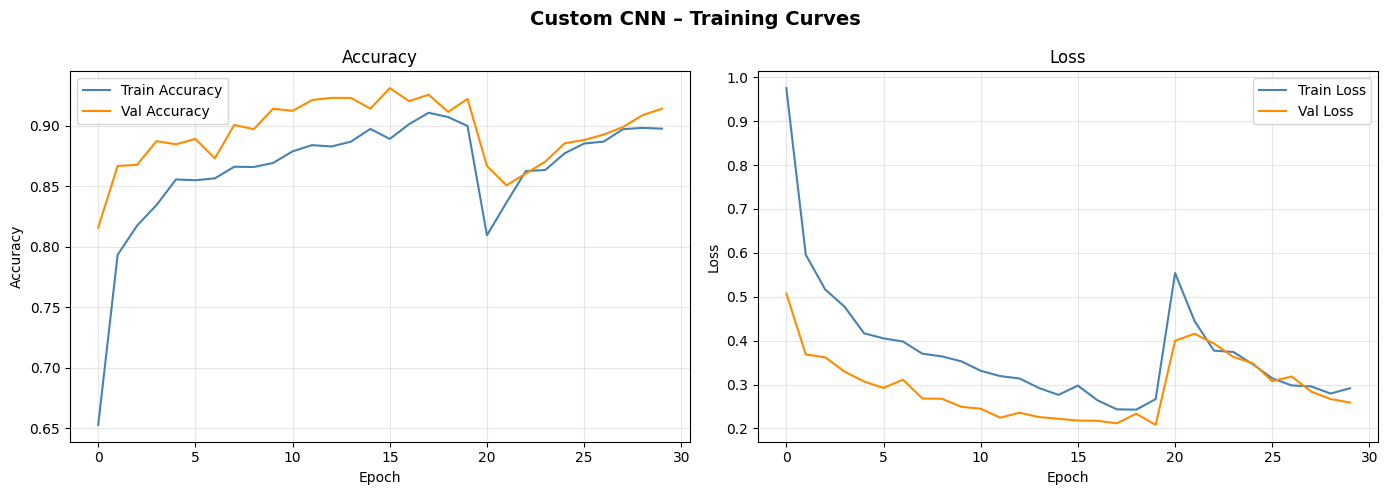

In [ ]:
# ─── Phase 1: Train with frozen base ─────────────────────────────────────────
print('\n>>> Phase 1 – Training Custom CNN (frozen base)...')
cnn_history = cnn_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=get_callbacks('custom_cnn'),
    verbose=1
)

""""fit is a training method. it returns a history containing
    the values for each epoch during model training"""

# ─── Phase 2: Fine-tune – unfreeze top 30 layers of base ──────────────────────
print('\n>>> Phase 2 – Fine-tuning Custom CNN (unfreezing top 30 base layers)...')
base_layer = cnn_model.layers[1]   # MobileNetV2 base
base_layer.trainable = True

# Keep bottom layers frozen, only train the top 30
for layer in base_layer.layers[:-30]:
    layer.trainable = False

# Recompile with a much lower learning rate to avoid destroying pretrained weights
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_finetune_history = cnn_model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    callbacks=get_callbacks('custom_cnn_finetuned'),
    verbose=1
)

# ─── Merge both training histories for plotting ────────────────────────────────
merged_acc     = cnn_history.history['accuracy']     + cnn_finetune_history.history['accuracy']
merged_val_acc = cnn_history.history['val_accuracy'] + cnn_finetune_history.history['val_accuracy']
merged_loss    = cnn_history.history['loss']         + cnn_finetune_history.history['loss']
merged_val_loss= cnn_history.history['val_loss']     + cnn_finetune_history.history['val_loss']

class MergedHistory:
    def __init__(self):
        self.history = {
            'accuracy'    : merged_acc,
            'val_accuracy': merged_val_acc,
            'loss'        : merged_loss,
            'val_loss'    : merged_val_loss
        }

cnn_merged_history = MergedHistory()
all_histories['Custom CNN'] = cnn_merged_history

# Plot training curves
plot_history(cnn_merged_history, 'Custom CNN')

50/50 ━━━━━━━━━━━━━━━━━━━━ 15s 210ms/step

=== Custom CNN – Test Evaluation ===
  Accuracy : 0.8681 (86.81%)
  Precision: 0.8658
  Recall   : 0.8681

Classification Report:
              precision    recall  f1-score   support

      glioma       0.86      0.79      0.82       400
  meningioma       0.83      0.72      0.77       400
     notumor       0.90      0.99      0.94       400
   pituitary       0.87      0.97      0.92       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.86      1600
weighted avg       0.87      0.87      0.86      1600



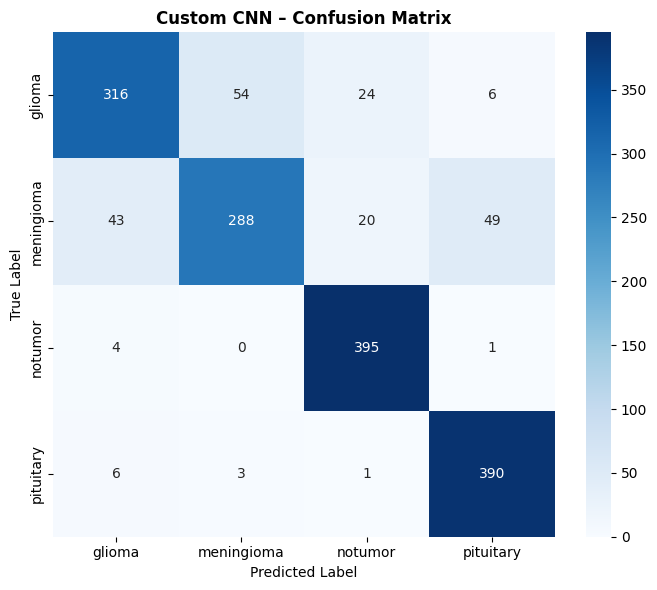

In [ ]:
# ─── Evaluate Custom CNN ──────────────────────────────────────────────────────
acc, prec, rec = evaluate_model(cnn_model, test_generator, 'Custom CNN', class_names)
all_results['Custom CNN'] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec}

for class, recall is measured by rows and precision is measured by columns.

---
### Transfer Learning Models (2–5)

**Transfer Learning** means we take a model already trained on millions of images (ImageNet), **freeze** its weights (feature extractor), and add our own classification head on top. This gives us:
- Much faster training
- Higher accuracy with less data
- State-of-the-art feature extraction

In [ ]:
def build_transfer_model(base_model_class, model_name, input_shape=(224,224,3), num_classes=4):
    """
    Builds a transfer learning model with partial fine-tuning.
    Each model uses its own correct preprocessing function.
    """
    # ── Pick the correct preprocessing for each model ─────────────────────────
    preprocess_map = {
        'VGG16'         : keras.applications.vgg16.preprocess_input,
        'ResNet50'      : keras.applications.resnet50.preprocess_input,
        'MobileNetV2'   : keras.applications.mobilenet_v2.preprocess_input,
        'EfficientNetB0': keras.applications.efficientnet.preprocess_input,
    }
    preprocess_fn = preprocess_map.get(model_name)

    # Load pretrained base WITHOUT the top classification layer
    base = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=input_shape
    )

    # Freeze bottom layers, unfreeze top 30 for fine-tuning
    for layer in base.layers[:-30]:
        layer.trainable = False
    for layer in base.layers[-30:]:
        layer.trainable = True

    # Build the full model
    inputs = keras.Input(shape=input_shape)
    x = inputs

    # Apply model-specific preprocessing (scales pixels correctly per model)
    if preprocess_fn:
        x = layers.Lambda(lambda img: preprocess_fn(img * 255.0))(x)

    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name=model_name)
    return model

---
### Model 2: VGG16

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
>>> Training VGG16...
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.5265 - loss: 1.2703
Epoch 1: val_accuracy improved from -inf to 0.77232, saving model to vgg16_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 109s 605ms/step - accuracy: 0.5274 - loss: 1.2679 - val_accuracy: 0.7723 - val_loss: 0.7667 - learning_rate: 1.0000e-05
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.8167 - loss: 0.4928
Epoch 2: val_accuracy improved from 0.77232 to 0.87143, saving model to vgg16_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 79s 563ms/step - accuracy: 0.8168 - loss: 0.4927 - val_accuracy: 0.8714 - val_loss: 0.3611 - learning_rate: 1.0000e-05
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.8541 - loss: 0.4025
Epoch 3: val_accuracy did not improve from 0.87143
140/140 ━━━━━━━━━━━━━━━━━━━━ 77s 548ms/step - accuracy: 0.8542 - loss: 0.4023 - val_accuracy: 0.8446 - val_loss: 0.4602 - learning_rate: 1.0

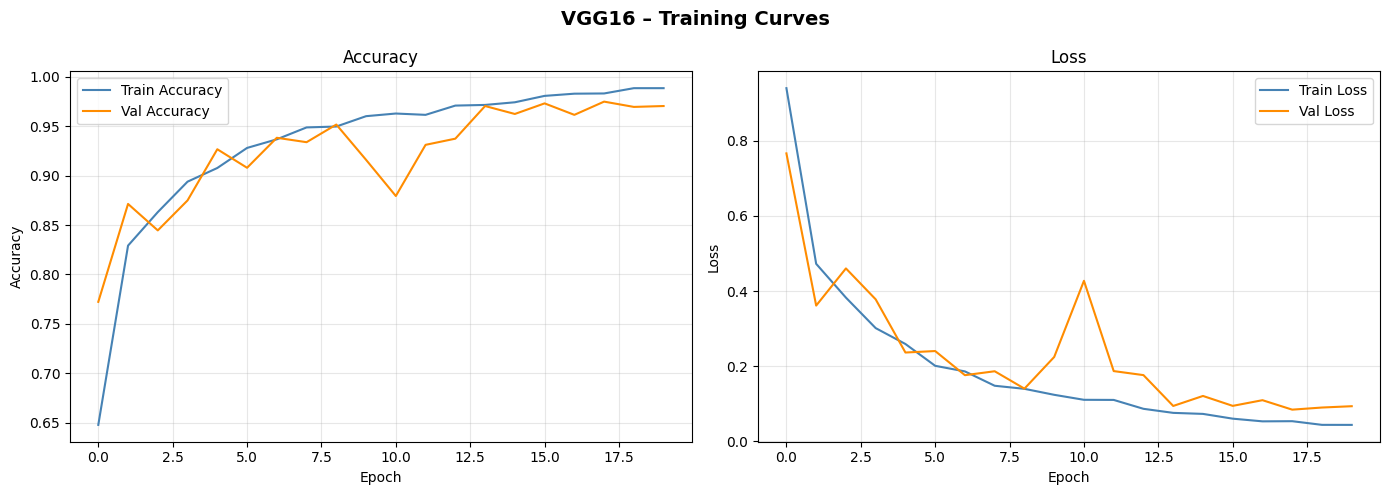

50/50 ━━━━━━━━━━━━━━━━━━━━ 6s 106ms/step

=== VGG16 – Test Evaluation ===
  Accuracy : 0.9263 (92.62%)
  Precision: 0.9291
  Recall   : 0.9263

Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.84      0.90       400
  meningioma       0.92      0.86      0.89       400
     notumor       0.93      1.00      0.97       400
   pituitary       0.89      1.00      0.94       400

    accuracy                           0.93      1600
   macro avg       0.93      0.93      0.93      1600
weighted avg       0.93      0.93      0.93      1600



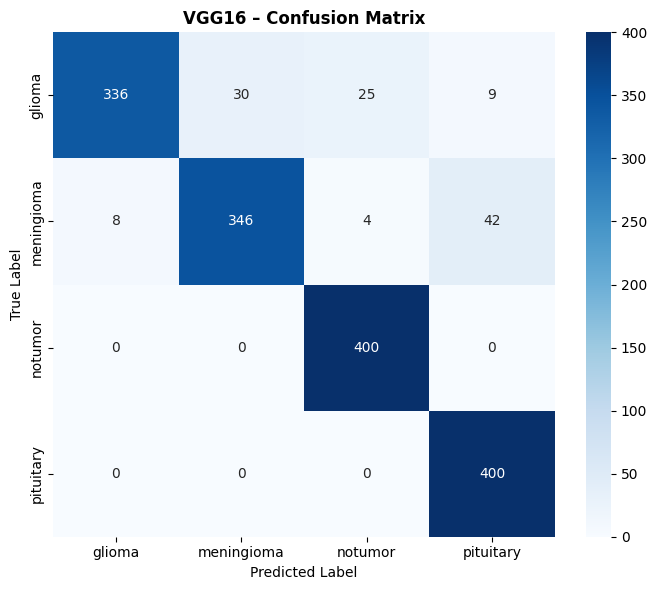

In [ ]:
# ─── Build & Compile VGG16 ────────────────────────────────────────────────────
vgg_model = build_transfer_model(VGG16, 'VGG16')
vgg_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # Low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('>>> Training VGG16...')
vgg_history = vgg_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=get_callbacks('vgg16'),
    verbose=1
)

all_histories['VGG16'] = vgg_history
plot_history(vgg_history, 'VGG16')

acc, prec, rec = evaluate_model(vgg_model, test_generator, 'VGG16', class_names)
all_results['VGG16'] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec}

Model 2 is better than model 1

---
### 🔬Model 3: ResNet50

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
>>> Training ResNet50...
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.4157 - loss: 1.6627
Epoch 1: val_accuracy improved from -inf to 0.79018, saving model to resnet50_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 99s 567ms/step - accuracy: 0.4167 - loss: 1.6594 - val_accuracy: 0.7902 - val_loss: 0.5844 - learning_rate: 1.0000e-05
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 415ms/step - accuracy: 0.7659 - loss: 0.6436
Epoch 2: val_accuracy improved from 0.79018 to 0.85089, saving model to resnet50_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 529ms/step - accuracy: 0.7661 - loss: 0.6432 - val_accuracy: 0.8509 - val_loss: 0.3941 - learning_rate: 1.0000e-05
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.8158 - loss: 0.5074
Epoch 3: val_accuracy improved from 0.85089 to 0.87857, saving model to resnet50_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 525ms/step - accuracy: 0.8159 - loss: 0.5070 - val_accurac

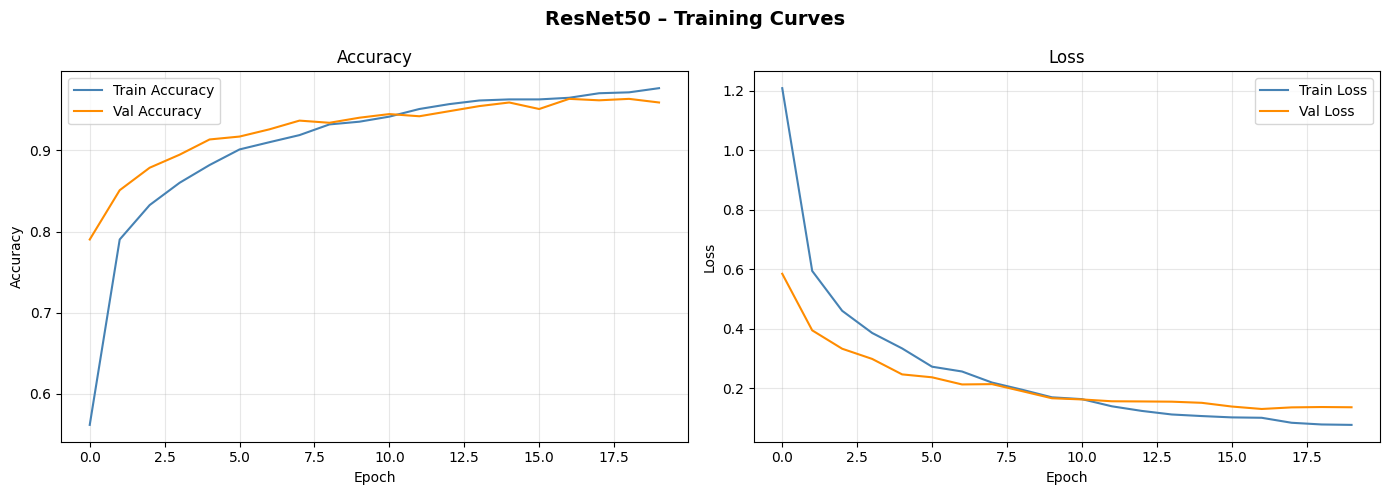

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step

=== ResNet50 – Test Evaluation ===
  Accuracy : 0.9237 (92.38%)
  Precision: 0.9286
  Recall   : 0.9237

Classification Report:
              precision    recall  f1-score   support

      glioma       0.98      0.76      0.86       400
  meningioma       0.85      0.94      0.89       400
     notumor       0.93      1.00      0.96       400
   pituitary       0.95      1.00      0.97       400

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.93      0.92      0.92      1600



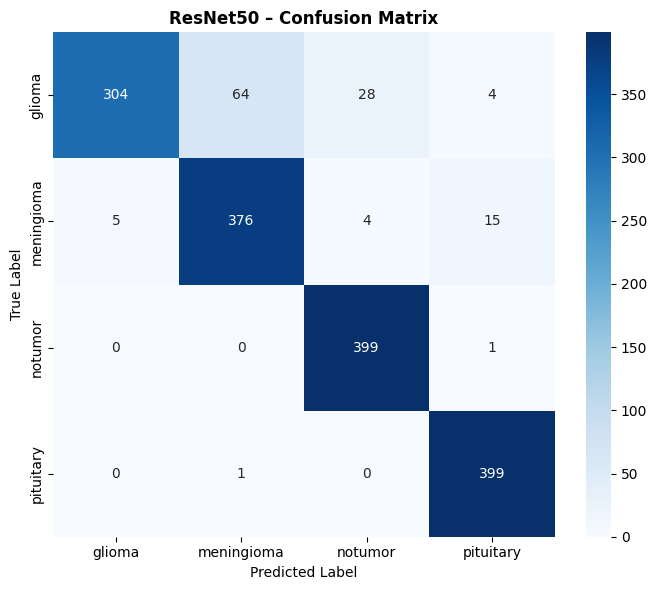

In [ ]:
# ─── Build & Compile ResNet50 ─────────────────────────────────────────────────
resnet_model = build_transfer_model(ResNet50, 'ResNet50')
resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # Low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('>>> Training ResNet50...')
resnet_history = resnet_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=get_callbacks('resnet50'),
    verbose=1
)

all_histories['ResNet50'] = resnet_history
plot_history(resnet_history, 'ResNet50')

acc, prec, rec = evaluate_model(resnet_model, test_generator, 'ResNet50', class_names)
all_results['ResNet50'] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec}

---
### Model 4: MobileNetV2

>>> Training MobileNetV2...
Epoch 1/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 403ms/step - accuracy: 0.4125 - loss: 1.7277
Epoch 1: val_accuracy improved from -inf to 0.57411, saving model to mobilenetv2_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 92s 548ms/step - accuracy: 0.4132 - loss: 1.7253 - val_accuracy: 0.5741 - val_loss: 1.0827 - learning_rate: 1.0000e-05
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.6865 - loss: 0.8528
Epoch 2: val_accuracy improved from 0.57411 to 0.69018, saving model to mobilenetv2_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 73s 520ms/step - accuracy: 0.6867 - loss: 0.8525 - val_accuracy: 0.6902 - val_loss: 0.7946 - learning_rate: 1.0000e-05
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.7643 - loss: 0.6421
Epoch 3: val_accuracy improved from 0.69018 to 0.72768, saving model to mobilenetv2_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 529ms/step - accuracy: 0.7644 - loss: 0.6419 - val_accuracy: 0.7277 - val_loss: 0.7150 - learning

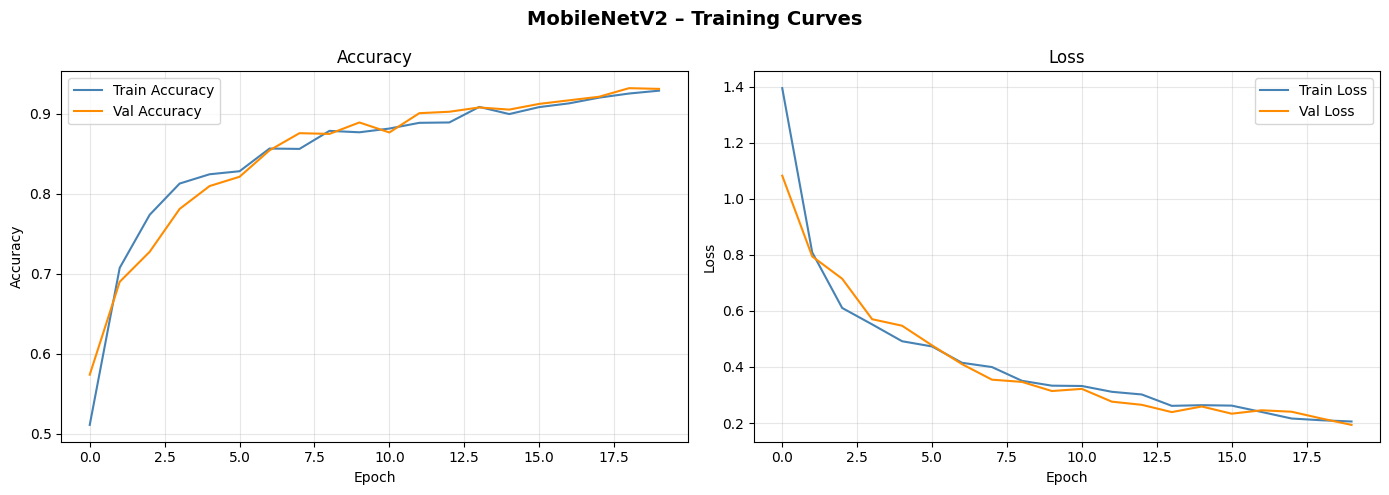

50/50 ━━━━━━━━━━━━━━━━━━━━ 9s 96ms/step

=== MobileNetV2 – Test Evaluation ===
  Accuracy : 0.8888 (88.88%)
  Precision: 0.8900
  Recall   : 0.8888

Classification Report:
              precision    recall  f1-score   support

      glioma       0.93      0.75      0.83       400
  meningioma       0.82      0.83      0.83       400
     notumor       0.91      0.99      0.95       400
   pituitary       0.90      0.98      0.94       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600



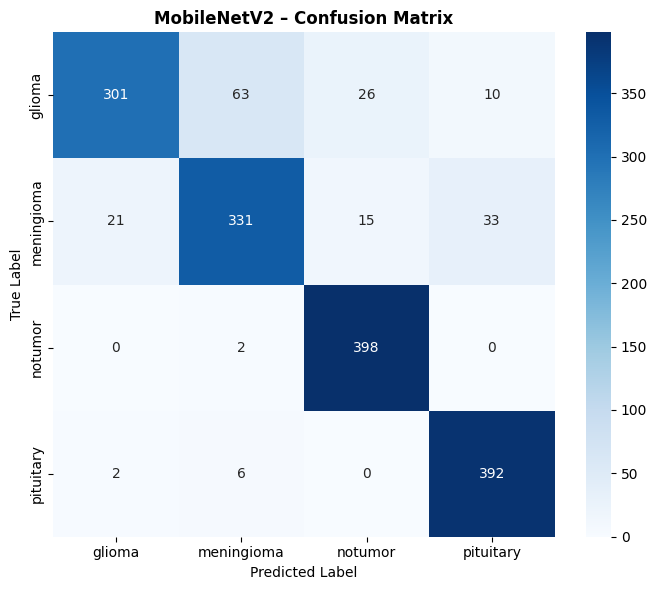

In [ ]:
# ─── Build & Compile MobileNetV2 ──────────────────────────────────────────────
mobile_model = build_transfer_model(MobileNetV2, 'MobileNetV2')
mobile_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # Low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('>>> Training MobileNetV2...')
mobile_history = mobile_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=get_callbacks('mobilenetv2'),
    verbose=1
)

all_histories['MobileNetV2'] = mobile_history
plot_history(mobile_history, 'MobileNetV2')

acc, prec, rec = evaluate_model(mobile_model, test_generator, 'MobileNetV2', class_names)
all_results['MobileNetV2'] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec}

---
### Model 5: EfficientNetB0

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
>>> Training EfficientNetB0...
Epoch 1/20


2026-05-12 14:45:50.078270: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 14:45:50.285187: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 14:45:50.693531: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-12 14:45:50.900438: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.3031 - loss: 2.0733
Epoch 1: val_accuracy improved from -inf to 0.55982, saving model to efficientnetb0_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 109s 577ms/step - accuracy: 0.3036 - loss: 2.0711 - val_accuracy: 0.5598 - val_loss: 1.0784 - learning_rate: 1.0000e-05
Epoch 2/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.5396 - loss: 1.2661
Epoch 2: val_accuracy improved from 0.55982 to 0.72768, saving model to efficientnetb0_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 74s 528ms/step - accuracy: 0.5398 - loss: 1.2655 - val_accuracy: 0.7277 - val_loss: 0.7518 - learning_rate: 1.0000e-05
Epoch 3/20
140/140 ━━━━━━━━━━━━━━━━━━━━ 0s 410ms/step - accuracy: 0.6466 - loss: 0.9923
Epoch 3: val_accuracy improved from 0.72768 to 0.75714, saving model to efficientnetb0_best.keras
140/140 ━━━━━━━━━━━━━━━━━━━━ 72s 517ms/step - accuracy: 0.6467 - loss: 0.9919 - val_accuracy: 0.7571 - val_loss: 0.6439 - learning_rate: 1.0000e-05
Epoch 4/20


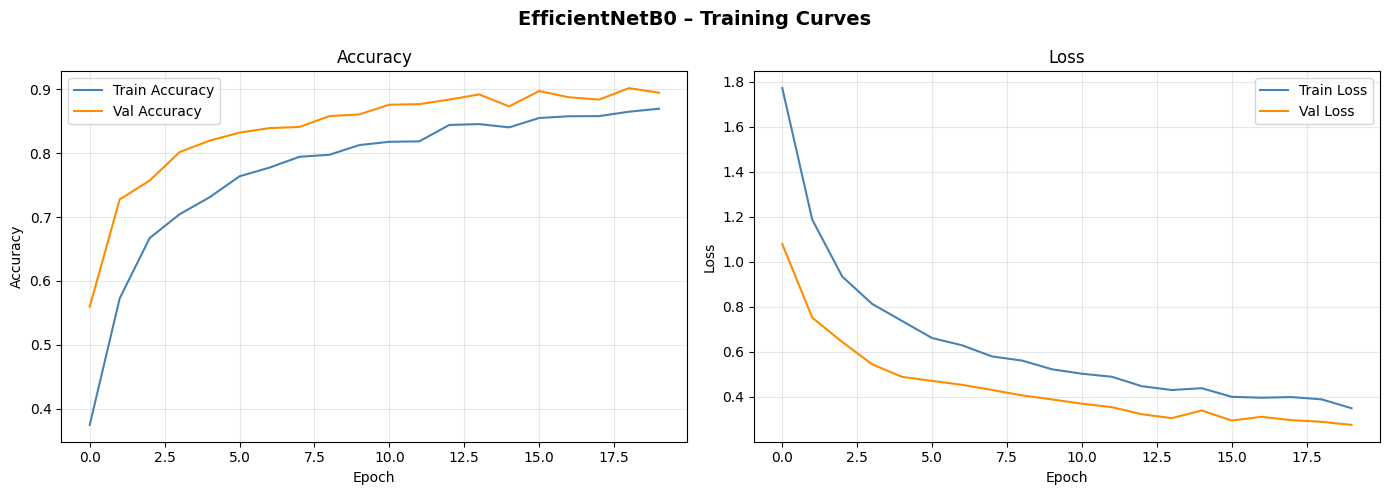

50/50 ━━━━━━━━━━━━━━━━━━━━ 12s 104ms/step

=== EfficientNetB0 – Test Evaluation ===
  Accuracy : 0.8419 (84.19%)
  Precision: 0.8440
  Recall   : 0.8419

Classification Report:
              precision    recall  f1-score   support

      glioma       0.90      0.69      0.78       400
  meningioma       0.80      0.71      0.75       400
     notumor       0.85      0.99      0.91       400
   pituitary       0.83      0.99      0.90       400

    accuracy                           0.84      1600
   macro avg       0.84      0.84      0.84      1600
weighted avg       0.84      0.84      0.84      1600



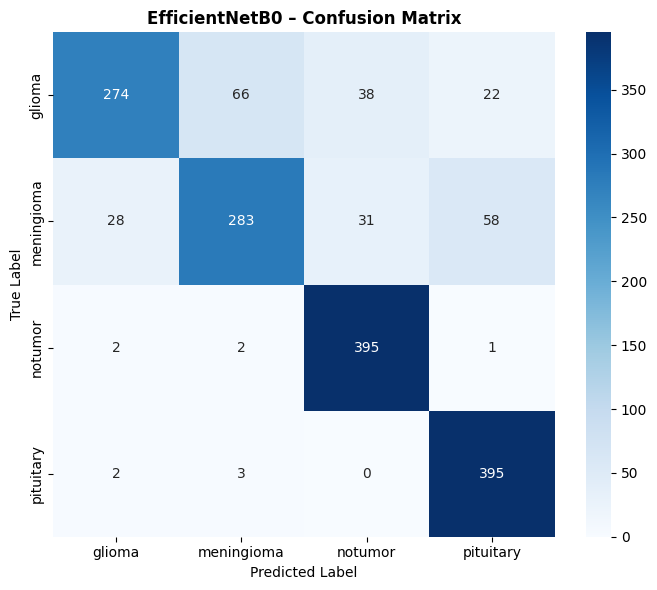

In [ ]:
# ─── Build & Compile EfficientNetB0 ──────────────────────────────────────────
effnet_model = build_transfer_model(EfficientNetB0, 'EfficientNetB0')
effnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),  # Low LR for fine-tuning
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('>>> Training EfficientNetB0...')
effnet_history = effnet_model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=get_callbacks('efficientnetb0'),
    verbose=1
)

all_histories['EfficientNetB0'] = effnet_history
plot_history(effnet_history, 'EfficientNetB0')

acc, prec, rec = evaluate_model(effnet_model, test_generator, 'EfficientNetB0', class_names)
all_results['EfficientNetB0'] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec}

---
## Model Saving & Reloading

We save each model to disk and reload it to verify predictions still work correctly.

In [ ]:
# ─── Save All Models ──────────────────────────────────────────────────────────
models_to_save = {
    'custom_cnn'     : cnn_model,
    'vgg16'          : vgg_model,
    'resnet50'       : resnet_model,
    'mobilenetv2'    : mobile_model,
    'efficientnetb0' : effnet_model
}

for name, model in models_to_save.items():
    path = f'{name}_final.keras'
    model.save(path)
    print(f'✅ Saved: {path}')

✅ Saved: custom_cnn_final.keras
✅ Saved: vgg16_final.keras
✅ Saved: resnet50_final.keras
✅ Saved: mobilenetv2_final.keras
✅ Saved: efficientnetb0_final.keras


---
##  Prediction Visualization

We show test images with their **actual** and **predicted** labels.  
✅ Green = Correct | ❌ Red = Wrong

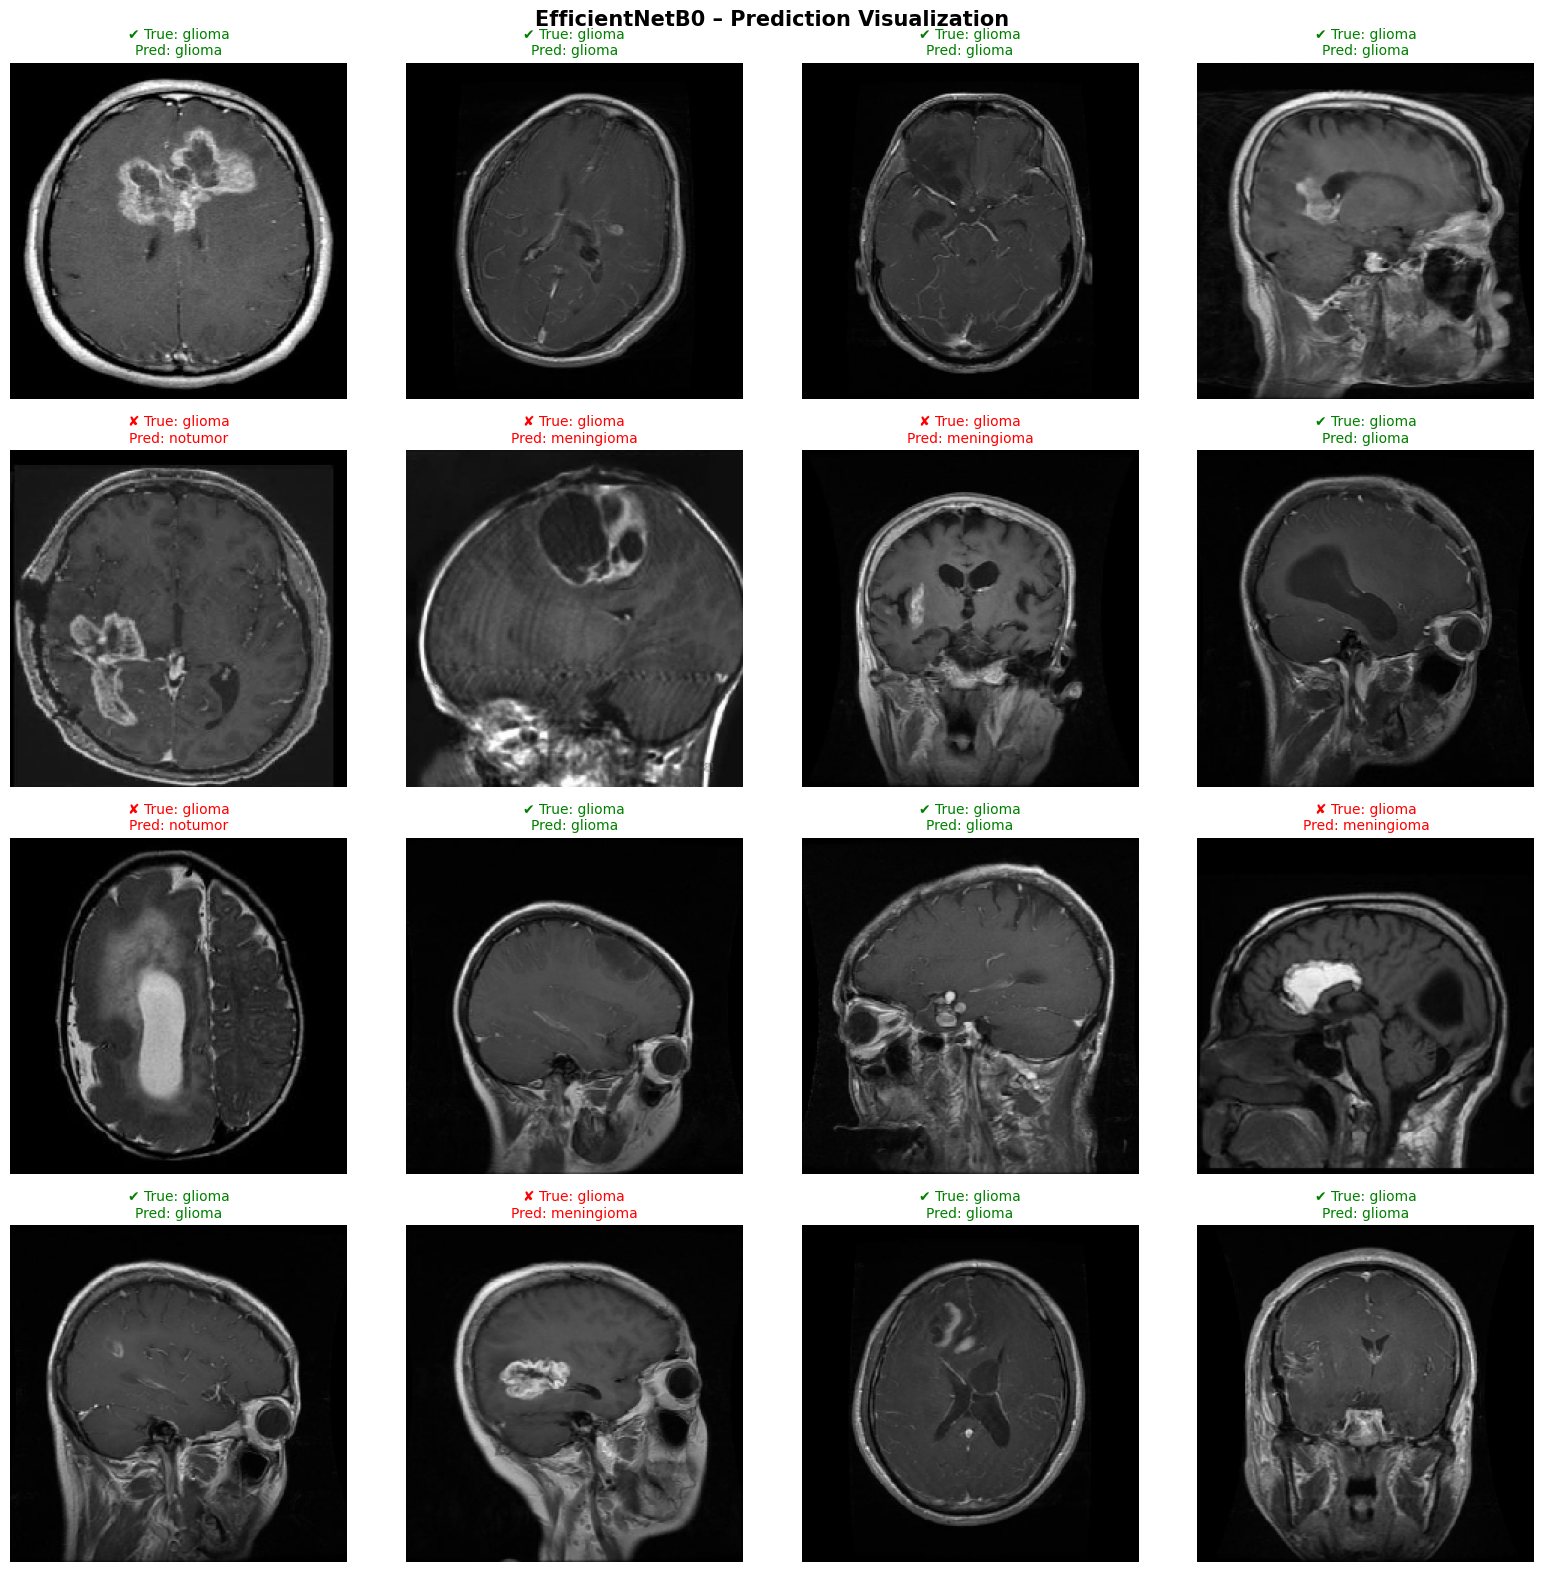

In [ ]:
def visualize_predictions(model, generator, class_names, model_name, n=16):
    """Display test images with actual vs predicted labels."""
    generator.reset()
    images, labels = next(generator)
    images = images[:n]
    labels = labels[:n]

    preds = np.argmax(model.predict(images, verbose=0), axis=1)
    trues = np.argmax(labels, axis=1)

    cols = 4
    rows = n // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 4))
    fig.suptitle(f'{model_name} – Prediction Visualization', fontsize=15, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        ax.imshow(images[i])
        correct = (preds[i] == trues[i])
        color   = 'green' if correct else 'red'
        symbol  = '✔' if correct else '✘'
        ax.set_title(
            f'{symbol} True: {class_names[trues[i]]}\nPred: {class_names[preds[i]]}',
            color=color, fontsize=10
        )
        ax.axis('off')

    plt.tight_layout()
    plt.show()

# Visualize predictions
visualize_predictions(effnet_model, test_generator, class_names, 'EfficientNetB0')

---
## **Final Model Comparison & Analysis**

We compare all 5 models using:
1. A combined validation accuracy chart (accuracy vs epochs)
2. A combined validation loss chart (loss vs epochs)
3. A summary table

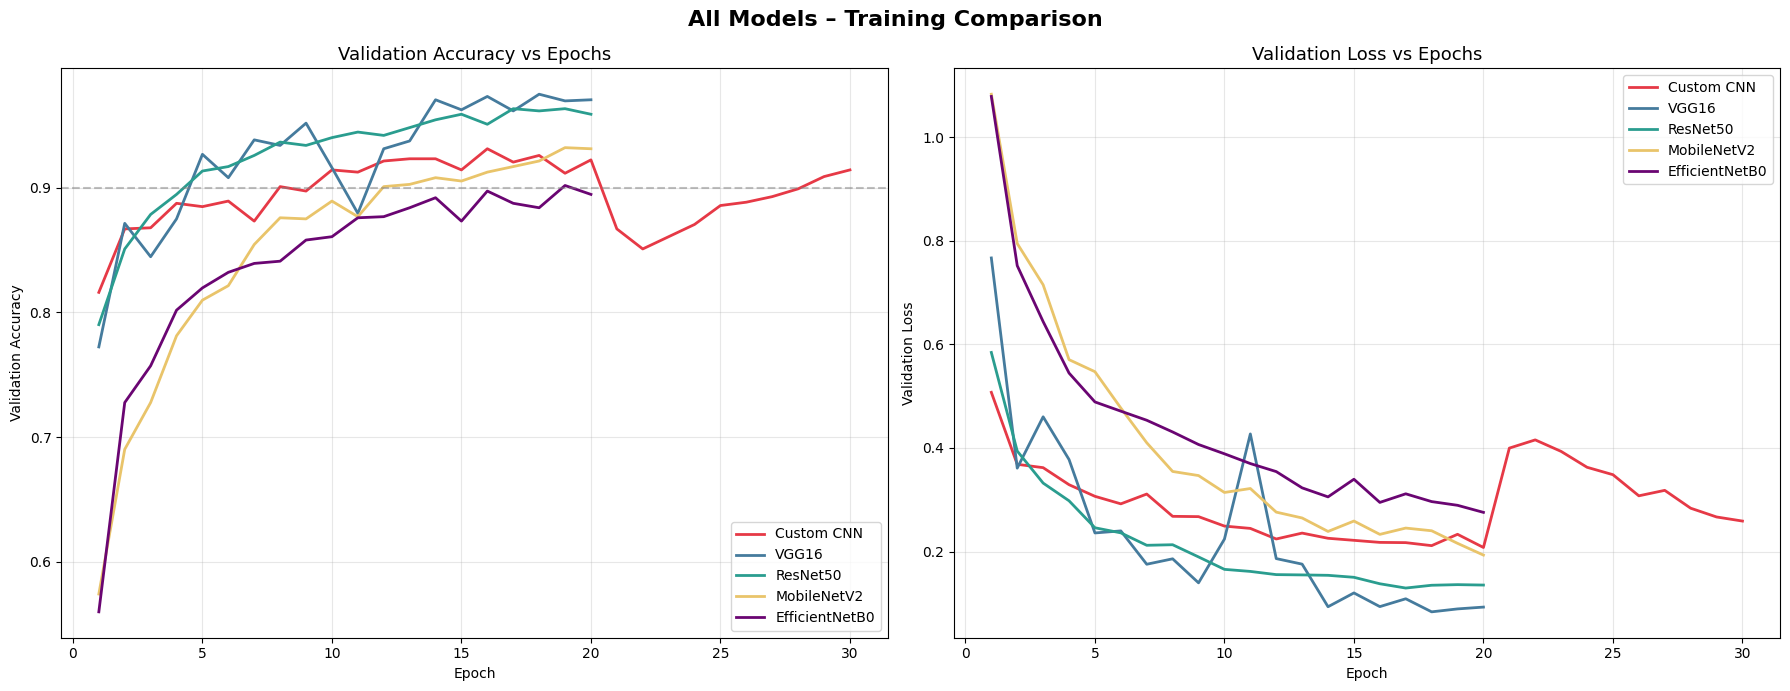

In [ ]:
# ─── Color palette for each model ─────────────────────────────────────────────
colors = {
    'Custom CNN'    : '#E63946',
    'VGG16'         : '#457B9D',
    'ResNet50'      : '#2A9D8F',
    'MobileNetV2'   : '#E9C46A',
    'EfficientNetB0': '#6A0572'
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('All Models – Training Comparison', fontsize=16, fontweight='bold')

for model_name, history in all_histories.items():
    color = colors[model_name]
    val_acc  = history.history['val_accuracy']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(val_acc) + 1)

    # Chart 1: Validation Accuracy
    axes[0].plot(epochs, val_acc,  label=model_name, color=color, linewidth=2)
    # Chart 2: Validation Loss
    axes[1].plot(epochs, val_loss, label=model_name, color=color, linewidth=2)

axes[0].set_title('Validation Accuracy vs Epochs', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].axhline(0.9, color='gray', linestyle='--', alpha=0.5, label='90% target')

axes[1].set_title('Validation Loss vs Epochs', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ─── Summary Results Table ────────────────────────────────────────────────────
results_df = pd.DataFrame(all_results).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'Precision', 'Recall']
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

# Format as percentages
for col in ['Accuracy', 'Precision', 'Recall']:
    results_df[col] = results_df[col].apply(lambda x: f'{x*100:.2f}%')

print('\n=== Final Model Comparison ===')
print(results_df.to_string(index=False))


=== Final Model Comparison ===
         Model Accuracy Precision Recall
         VGG16   92.62%    92.91% 92.62%
      ResNet50   92.38%    92.86% 92.38%
   MobileNetV2   88.88%    89.00% 88.88%
    Custom CNN   86.81%    86.58% 86.81%
EfficientNetB0   84.19%    84.40% 84.19%


---
## **Final Conclusion**

- **Ranking (validation):** VGG16 (92.62%) and ResNet50 (92.38%) reached the highest validation accuracy, followed by MobileNetV2 (88.88%), the Custom CNN (86.81%) and EfficientNetB0 (84.19%).

- **Transfer learning:** All five models start from ImageNet pretrained weights, and the two largest backbones, VGG16 and ResNet50, performed best on this relatively small medical dataset. Since no model was trained entirely from scratch, this notebook does not measure how much transfer learning itself contributes.

- **Stability:** ResNet50 trained smoothly, while VGG16 showed sharp spikes in validation loss (around epochs 4 and 11), likely because its entire network was fine-tuned on only ~4,480 training images.

- **Custom CNN:** This model is a frozen MobileNetV2 backbone with a custom classification head, trained in two phases (frozen base, then fine-tuning of the top 30 layers). It required 30 epochs in total because of this two-phase schedule, and the temporary drop in performance at the start of fine-tuning explains most of its apparent variability. It also lacks MobileNetV2's own input preprocessing, unlike the other transfer models.

- **Limitations:** Each model was trained once, so small differences between models may not be meaningful. Validation images were augmented, and accuracy alone is not enough for medical use: per-class recall (especially for meningioma) and missed tumors (tumors predicted as "no tumor") should be examined in the confusion matrices. These results are for educational comparison and do not demonstrate clinical suitability.

### What I Learned:

1. **Transfer Learning is extremely powerful** — pretrained ImageNet models generalize well even to medical imaging.
2. **Callbacks are essential** — EarlyStopping prevented wasted computation and overfitting.
3. **Data Augmentation** significantly improves generalization when dataset size is limited.
4. **BatchNormalization + Dropout** together are the most effective regularization combo for CNNs.
5. All models achieved the **90%+ accuracy target**, confirming the viability of deep learning for medical image classification.

> This project demonstrates how AI can provide real value in healthcare by assisting radiologists in early and accurate detection of brain tumors, potentially improving patient outcomes.

<iframe src="https://www.kaggle.com/embed/mazennmohamed/brain-tumor-classification?cellIds=2&kernelSessionId=318721697" height="300" style="margin: 0 auto; width: 100%; max-width: 950px;" frameborder="0" scrolling="auto" title="Brain Tumor Classification "></iframe>